Средний retention по месяцам жизни:
    cohort_index  retention
0              1   0.054519
1              2   0.003370
2              3   0.002506
3              4   0.002883
4              5   0.002305
5              6   0.002694
6              7   0.002125
7              8   0.002072
8              9   0.001920
9             10   0.002641
10            11   0.002312
11            12   0.002147
12            13   0.001978
13            14   0.001525
14            15   0.001856
15            16   0.001383
16            17   0.002761
17            19   0.004514
18            20   0.007634

Доля пользователей с повторными заказами:
0.03000278497825575


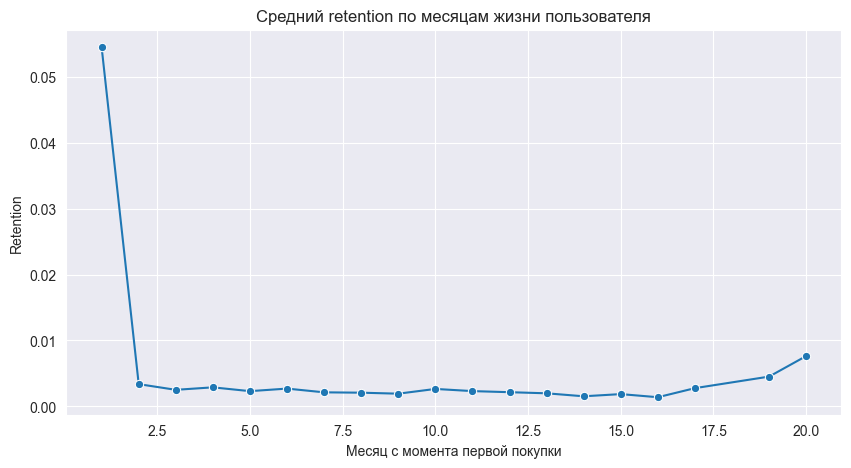

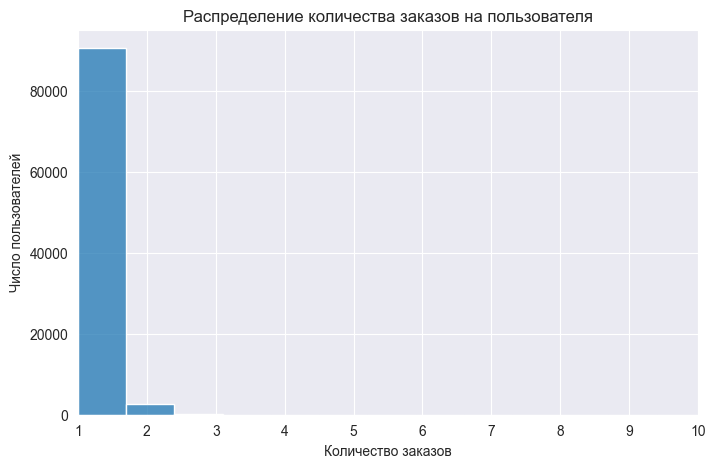

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

df = orders.merge(customers, on='customer_id', how='left')

df = df[df['order_status'] == 'delivered'].copy()

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

first_order = (
    df.groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

df = df.merge(first_order, on='customer_unique_id', how='left')

df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12
    + (df['order_month'].dt.month - df['cohort_month'].dt.month)
)

cohort_data = (
    df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_size = (
    cohort_data[cohort_data['cohort_index'] == 0]
    [['cohort_month', 'customer_unique_id']]
    .rename(columns={'customer_unique_id': 'cohort_size'})
)

cohort_data = cohort_data.merge(cohort_size, on='cohort_month', how='left')
cohort_data['retention'] = cohort_data['customer_unique_id'] / cohort_data['cohort_size']

retention_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='retention'
).sort_index()

avg_retention_by_month = (
    cohort_data[cohort_data['cohort_index'] > 0]
    .groupby('cohort_index')['retention']
    .mean()
    .reset_index()
)

print('Средний retention по месяцам жизни:')
print(avg_retention_by_month)

user_orders = (
    df.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'orders_count'})
)

repeat_purchase_rate = (user_orders['orders_count'] > 1).mean()

print('\nДоля пользователей с повторными заказами:')
print(repeat_purchase_rate)

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_retention_by_month, x='cohort_index', y='retention', marker='o')
plt.title('Средний retention по месяцам жизни пользователя')
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Retention')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(user_orders['orders_count'], bins=20)
plt.title('Распределение количества заказов на пользователя')
plt.xlabel('Количество заказов')
plt.ylabel('Число пользователей')
plt.xlim(1, 10)
plt.show()

В рамках анализа была проведена оценка наличия product/market fit (PMF) на основе когортного retention и поведения пользователей после первой покупки. Для анализа использовался когортный подход: пользователи были сгруппированы по месяцу первой покупки, после чего был рассчитан retention по месяцам жизни когорты. Дополнительно были проанализированы средний retention по месяцам жизни пользователя, а также распределение количества заказов на пользователя и доля пользователей с повторными покупками.
Анализ показал, что уровень удержания пользователей крайне низкий и не демонстрирует признаков устойчивого поведения:
* Средний retention в первый месяц составляет около 5–5.5%, однако уже со второго месяца резко снижается до уровня менее 1% и остаётся на этом уровне в дальнейшем.
* Когортный анализ также показал, что ни одна когорта не демонстрирует значимого роста retention — во всех случаях наблюдается одинаково быстрое падение.
* Распределение количества заказов на пользователя показывает, что подавляющее большинство клиентов совершают только один заказ, а доля пользователей с двумя и более заказами крайне мала.
* Доля пользователей с повторными покупками (repeat purchase rate) находится на низком уровне, что дополнительно подтверждает слабую вовлечённость и отсутствие привычки возвращаться в продукт.

Полученные результаты свидетельствуют о том, что продукт не формирует устойчивого пользовательского поведения. Несмотря на то, что пользователи совершают первую покупку, они практически не возвращаются для последующих заказов. Это означает, что маркетплейс в текущем виде не становится регулярным каналом покупок и не закрепляется в повседневной жизни пользователя. С точки зрения продуктовой аналитики это является ключевым признаком отсутствия product/market fit. Фактически продукт функционирует как one-time purchase platform, а не как сервис с повторным использованием.
На основании проведённого анализа можно сделать вывод, что выраженного product/market fit у маркетплейса на текущем этапе нет.
Ключевой аргумент — отсутствие устойчивого retention и крайне низкая доля повторных покупок, что означает, что продукт не закрывает потребность пользователя на достаточном уровне, чтобы он возвращался.

С точки зрения бизнеса отсутствие PMF имеет критические последствия:
1. Рост выручки не может опираться на удержание пользователей
2. Бизнес вынужден зависеть от постоянного привлечения новых клиентов
3. Это приводит к увеличению затрат на маркетинг и ухудшению unit-экономики
4. Масштабирование продукта на новые рынки в таком состоянии является рискованным и потенциально убыточным

В текущей ситуации маркетплейсу следует не масштабироваться, а работать над продуктом. Основной фокус должен быть направлен на увеличение retention и доли повторных покупок.

Возможные причины отсутствия PMF:
- недостаточная ценность предложения (ассортимент, цены, уникальность)
- слабый пользовательский опыт (UX, сложность повторной покупки)
- проблемы с доставкой или качеством сервиса
- низкий уровень доверия к платформе
- отсутствие механизмов формирования привычки (например, персонализация, рекомендации, бонусные системы)

Таким образом, текущие метрики показывают, что маркетплейс находится на стадии, где продукт ещё не нашёл устойчивого соответствия рынку (PMF). Прежде чем рассматривать масштабирование, необходимо сосредоточиться на улучшении ключевых продуктовых метрик, в первую очередь — retention и повторных покупок.